# Elements and Lattices

PyTao provides Pydantic models that let you query Tao element data into structured Python objects.
The two main classes are `Element` (a single lattice element) and `Lattice` (a collection of elements).

## Setup

In [1]:
from pytao import Tao

tao = Tao(init_file="$ACC_ROOT_DIR/bmad-doc/tao_examples/cesr/tao.init", plot="mpl")

Installed Tao version is lower than pytao's recommended and tested version. 
   You have Tao version: 2026-07-07
   Recommended version:  2026-07-09
Some features may not work as expected.  Please upgrade bmad.


## Getting a single Element

Use `tao.ele()` to get one element. By default, it loads a comprehensive set of data (twiss, orbit, attributes, floor coordinates, etc.).

In [2]:
ele = tao.ele("Q00W")
ele.name, ele.key

('Q00W', 'Quadrupole')

### Head information

Every element has a `head` with metadata: name, key (element type), position, indices, and capability flags.

In [3]:
ele.head

ElementHead(
    alias='Q00W',
    descrip='',
    has_ab_multipoles=True,
    has_ac_kick=False,
    has_control=False,
    has_floor=True,
    has_kt_multipoles=False,
    has_lord_slave=True,
    has_mat6=True,
    has_methods=True,
    has_multipoles_elec=True,
    has_photon=False,
    has_spin_taylor=False,
    has_taylor=False,
    has_twiss=True,
    has_wake=False,
    has_wall3d=0,
    is_on=True,
    ix_branch=0,
    ix_ele=870,
    key='Quadrupole',
    name='Q00W',
    num_cartesian_map=0,
    num_cylindrical_map=0,
    num_gen_gradients=0,
    num_grid_field=0,
    ref_time=7.21417751641456e-09,
    s=2.16275600000009,
    s_start=0.637956,
    type='',
    universe=1
)

### General attributes

General attributes are element-type-specific parameters like `L` (length), `k1` (quadrupole strength), etc.

In [4]:
ele.attribs

{'L': 1.524800000000091,
 'tilt': 0.0754952,
 'k1': -0.8417848364530158,
 'fringe_type': 'None',
 'fringe_at': 'Both_Ends',
 'spin_fringe_on': True,
 'r0_elec': 0.0,
 'r0_mag': 0.0,
 'fq1': 0.0,
 'fq2': 0.0,
 'x_pitch': 0.0,
 'y_pitch': 0.0,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'z_offset': 0.0,
 'hkick': 0.0,
 'vkick': 0.0,
 'bl_hkick': 0.0,
 'bl_vkick': 0.0,
 'b1_gradient': 14.85094057709878,
 'ptc_canonical_coords': True,
 'delta_ref_time': 5.086185347320325e-09,
 'p0c': 5288999975.314811,
 'e_tot': 5289000000.000001,
 'x_pitch_tot': 0.0,
 'y_pitch_tot': 0.0,
 'x_offset_tot': 0.0,
 'y_offset_tot': 0.0,
 'z_offset_tot': 0.0,
 'tilt_tot': 0.0754952,
 'ref_time_start': 2.127992169094236e-09,
 'integrator_order': 2,
 'num_steps': 64,
 'ds_step': 0.02382500000000142,
 'csr_ds_step': 0.0,
 'lord_pad1': 0.0,
 'lord_pad2': 0.0,
 'x1_limit': 0.0,
 'x2_limit': 0.0,
 'y1_limit': 0.0,
 'y2_limit': 0.0,
 'lord_status': 'Super_Lord',
 'slave_status': 'Minor_Slave',
 'aperture_at': 'Exit_End',
 'of

In [5]:
# Access general attributes which are element-specific:
ele.attribs["L"], ele.attribs.lord_status, ele.attribs.aperture_type

(1.524800000000091, 'Super_Lord', 'Rectangular')

You can also view units for these attributes like so:

In [6]:
ele.attrs["L"].units

'm'

The full set of attribute information provided by Tao can be inspected in `ele.attrs`:

In [7]:
ele.attrs

GeneralAttributes(
    attrs={
        'L': Attr(
            name='L',
            type='REAL',
            settable=False,
            data=1.524800000000091,
            units='m'
        ),
        'tilt': Attr(
            name='TILT',
            type='REAL',
            settable=False,
            data=0.0754952,
            units='rad'
        ),
        'k1': Attr(
            name='K1',
            type='REAL',
            settable=False,
            data=-0.8417848364530158,
            units='1/m^2'
        ),
        'fringe_type': Attr(
            name='FRINGE_TYPE',
            type='ENUM',
            settable=False,
            data='None',
            units=None
        ),
        'fringe_at': Attr(
            name='FRINGE_AT',
            type='ENUM',
            settable=False,
            data='Both_Ends',
            units=None
        ),
        'spin_fringe_on': Attr(
            name='SPIN_FRINGE_ON',
            type='LOGIC',
            settable=False,
    

### Twiss parameters

In [8]:
ele.twiss

ElementTwiss(
    alpha_a=-14.5306497921953,
    alpha_b=25.8281436293631,
    beta_a=15.9569604975133,
    beta_b=76.3766224115966,
    dalpha_dpz_a=-330.217881814612,
    dalpha_dpz_b=465.372281067964,
    dbeta_dpz_a=366.293827131603,
    dbeta_dpz_b=1607.40327209197,
    deta_dpz_a=-1.31078689730276,
    deta_dpz_b=0.077542150026579,
    deta_dpz_x=-1.33623745152148,
    deta_dpz_y=0.126869936796069,
    deta_ds_a=-0.121720793069142,
    deta_ds_b=-4.09604188903925e-05,
    deta_dsx=-0.124087902699568,
    deta_dsy=-0.0112767096416127,
    detap_dpz_a=-0.703120021002026,
    detap_dpz_b=-0.0356480151500083,
    detap_dpz_x=-0.709366488383933,
    detap_dpz_y=-0.183508814783342,
    eta_a=-0.125955667075685,
    eta_b=-0.00296751650073793,
    eta_x=-0.128166638603888,
    eta_y=-0.0126152324800141,
    etap_a=-0.114114719081798,
    etap_b=-4.40445098414486e-05,
    etap_x=-0.116363892194681,
    etap_y=-0.0106308883830499,
    gamma_a=13.2944982483653,
    gamma_b=8.74734941457128

### Orbit

In [9]:
ele.orbit

ElementOrbit(
    beta=-1.0,
    charge=0.0,
    direction=1,
    dt_ref=0.0,
    field=[0.0, 0.0],
    ix_ele=-1,
    location='Upstream_End',
    p0c=0.0,
    phase=[0.0, 0.0],
    px=0.0,
    py=0.0,
    pz=0.0,
    s=0.0,
    species='Not_Set!',
    spin=[0.0, 0.0, 0.0],
    state='Not_Set',
    t=0.0,
    x=0.0,
    y=0.0,
    z=0.0
)

### Floor coordinates

In [10]:
ele.floor

ElementFloorAll(
    which='model',
    beginning=ElementFloor(
        which='model',
        where='beginning',
        actual=ElementFloorPosition(
            x=0.0,
            y=0.0,
            z=0.637956,
            theta=0.0,
            phi=0.0,
            psi=0.0754952,
            wmat=array([[ 0.99715159, -0.07542351,  0.        ],
       [ 0.07542351,  0.99715159,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])
        ),
        reference=ElementFloorPosition(
            x=0.0,
            y=0.0,
            z=0.637956,
            theta=0.0,
            phi=0.0,
            psi=0.0,
            wmat=array([[ 1., -0.,  0.],
       [ 0.,  1.,  0.],
       [-0.,  0.,  1.]])
        ),
        slaves={}
    ),
    center=ElementFloor(
        which='model',
        where='center',
        actual=ElementFloorPosition(
            x=0.0,
            y=0.0,
            z=1.40035600000005,
            theta=0.0,
            phi=0.0,
            psi=0.0754952,


### Transfer matrix (mat6)

In [11]:
ele.mat6

ElementMat6(
    which='model',
    vec0=array([-5.96034007e-08, -2.80046616e-08, -7.05420754e-09, -2.13217042e-09,
        1.64134376e-05,  0.00000000e+00]),
    mat6=array([[ 2.13280675e+00,  2.06565046e+00,  1.06264456e-01,
        -5.19203611e-03,  0.00000000e+00, -8.32058018e-03],
       [ 1.72825682e+00,  2.13876037e+00,  1.85340334e-01,
         7.01049607e-02,  0.00000000e+00, -3.90942512e-03],
       [ 2.00805572e-01,  1.40422386e-01,  1.80785561e-01,
         1.07619865e+00,  0.00000000e+00, -9.84760915e-04],
       [ 1.80201468e-01,  1.67905099e-01, -8.91733320e-01,
         1.76484502e-01,  0.00000000e+00, -2.97649038e-04],
       [-6.15973697e-03, -9.84377110e-03, -1.94751404e-04,
        -4.57077370e-04,  1.00000000e+00,  4.28675359e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]),
    symplectic_error=5.10702591327572e-15
)

## Getting multiple Elements

Use `tao.eles()` to query multiple elements at once. It supports names, indices, ranges, wildcards, and key-based matching.

In [12]:
# By index range
elements = tao.eles("1:5")
for ele in elements:
    print(f"{ele.name:20s} key={ele.key:15s} s={ele.head.s:.3f}")

IP_L0                key=Marker          s=0.000
CLEO_SOL#3           key=Solenoid        s=0.622
DET_00W              key=Marker          s=0.622
CLEO_SOL#4           key=Solenoid        s=0.638
Q00W\CLEO_SOL        key=Sol_Quad        s=1.755


In [13]:
# By wildcard
quads = tao.eles("Q0*")
for q in quads:
    print(f"{q.name:20s} K1={q.attrs['K1'].data}")

Q00W                 K1=-0.8417848364530158
Q00W\CLEO_SOL        K1=-0.8417848364530158
Q00W#1               K1=-0.8417848364530158
Q01W                 K1=0.639155
Q02W                 K1=-0.206328
Q03W                 K1=-0.128947
Q04W                 K1=0.420143
Q05W                 K1=-0.373608
Q06W                 K1=0.421931
Q07W                 K1=-0.246488
Q08W                 K1=0.144685
Q09W                 K1=-0.19165
Q09E                 K1=-0.190367
Q08E                 K1=0.144685
Q07E                 K1=-0.246488
Q06E                 K1=0.421931
Q05E                 K1=-0.373608
Q04E                 K1=0.420143
Q03E                 K1=-0.128947
Q02E                 K1=-0.206328
Q01E                 K1=0.639155
Q00E                 K1=-0.8417848364530158
Q00E#1               K1=-0.8417848364530158
Q00E\CLEO_SOL        K1=-0.8417848364530158


In [14]:
# By element key - get all quadrupoles
all_quads = tao.eles("quad::*")
print(f"Found {len(all_quads)} quadrupoles")

Found 126 quadrupoles


## Controlling what data is loaded

Loading all data for many elements can be slow. You can control which fields are loaded.

In [15]:
# Minimal element - only head data
ele_minimal = tao.ele("Q00W", defaults=False)
print(f"twiss: {ele_minimal.twiss}")
print(f"orbit: {ele_minimal.orbit}")

twiss: None
orbit: None


In [16]:
# Only specific fields
ele_twiss_only = tao.ele("Q00W", defaults=False, twiss=True, attrs=True)
print(f"twiss: {ele_twiss_only.twiss is not None}")
print(f"orbit: {ele_twiss_only.orbit is not None}")

twiss: True
orbit: False


In [17]:
# Defaults on, but exclude orbit
ele_no_orbit = tao.ele("Q00W", orbit=False)
print(f"twiss: {ele_no_orbit.twiss is not None}")
print(f"orbit: {ele_no_orbit.orbit is not None}")

twiss: True
orbit: False


You can also change the global defaults for all future queries:

In [18]:
from pytao.model import Element

# See current defaults
print("Current defaults:", Element.DEFAULTS)

Current defaults: {'floor', 'multipoles', 'mat6', 'twiss', 'lord_slave', 'grid_field', 'attrs', 'photon', 'wake', 'bunch_params', 'chamber_walls', 'orbit', 'control_vars', 'wall3d'}


## Lattice objects

A `Lattice` is a collection of `Element`s. There are several constructors depending on what subset of the lattice you need.

In [19]:
from pytao.model import Lattice

# Load tracking elements (skips lords/markers)
lat = Lattice.from_tao_tracking(tao)
print(lat)

<Lattice which=model with 870 elements>


In [20]:
# Load unique (non-slave) elements
lat_unique = Lattice.from_tao_unique(tao)
print(lat_unique)

<Lattice which=model with 1010 elements>


In [21]:
# Load a subset by range
lat_subset = Lattice.from_tao_tracking(tao, track_start="1", track_end="20")
print(lat_subset)

<Lattice which=model with 20 elements>


### Accessing elements in a Lattice

Lattice objects provide convenient dictionaries for lookup.

In [22]:
# By name
by_name = lat.by_element_name
list(by_name.keys())[:10]

['BEGINNING',
 'IP_L0',
 'CLEO_SOL#3',
 'DET_00W',
 'CLEO_SOL#4',
 'Q00W\\CLEO_SOL',
 'Q00W#1',
 'D003',
 'DET_01W',
 'D004']

In [23]:
# By element type (key)
by_key = lat.by_element_key
print("Element types:", list(by_key.keys()))

Element types: ['Beginning_Ele', 'Marker', 'Solenoid', 'Sol_Quad', 'Quadrupole', 'Drift', 'Kicker', 'SBend', 'Wiggler', 'ELSeparator', 'Sextupole', 'RFCavity', 'Octupole']


In [24]:
# By index
by_index = lat.by_element_index
by_index[1].name

'IP_L0'

## Plotting with Element data

Since all data is in Python objects, it's easy to plot with matplotlib or any other library.

In [25]:
import matplotlib.pyplot as plt
import numpy as np

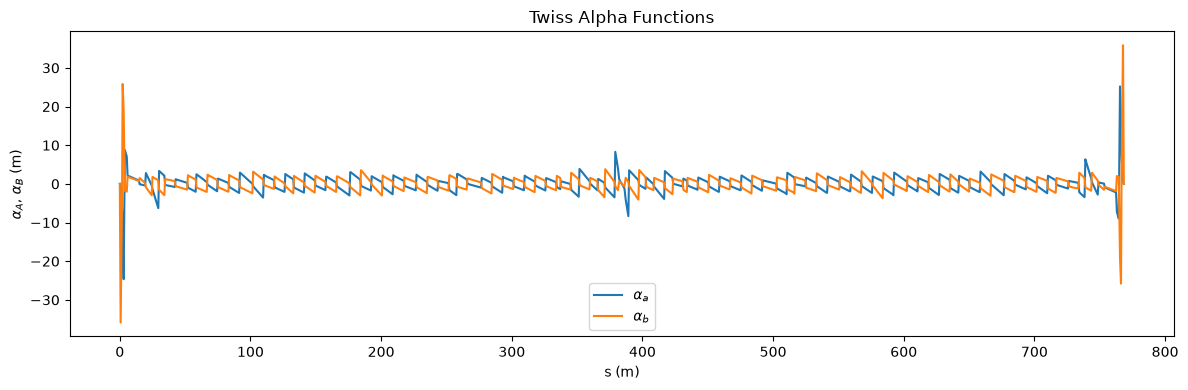

In [26]:
# Extract Twiss data from lattice elements
eles = lat.elements
s_values = [ele.head.s for ele in eles]
alpha_a = [ele.twiss.alpha_a for ele in eles]
alpha_b = [ele.twiss.alpha_b for ele in eles]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(s_values, alpha_a, label=r"$\alpha_a$")
ax.plot(s_values, alpha_b, label=r"$\alpha_b$")
ax.set_xlabel("s (m)")
ax.set_ylabel(r"$\alpha_A$, $\alpha_B$ (m)")
ax.set_title("Twiss Alpha Functions")
ax.legend()
plt.tight_layout()

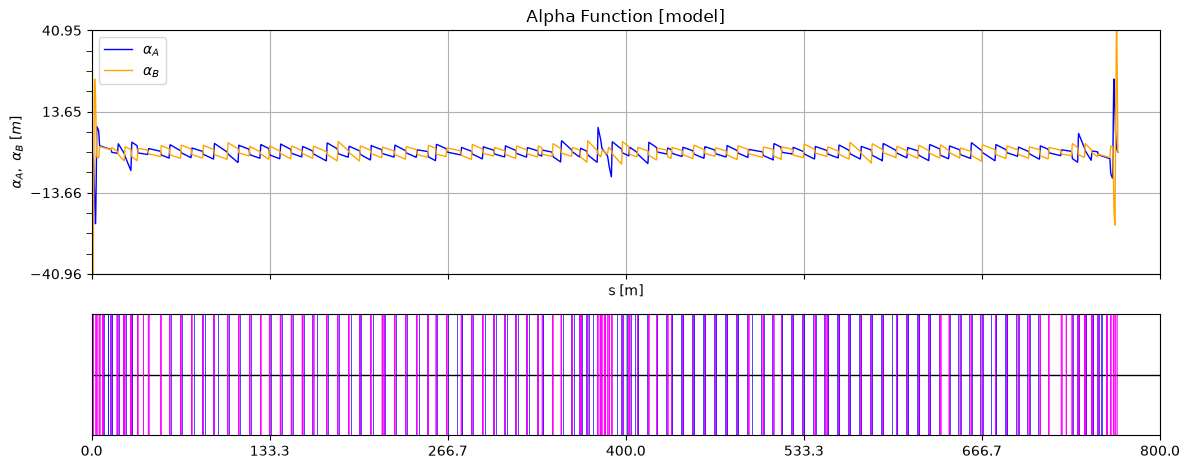

In [27]:
tao.plot("alpha", width=12)

## Saving and loading

Element and Lattice objects can be serialized to JSON, compressed JSON, or msgpack (the fastest!).

In [28]:
from pathlib import Path

lat_subset = Lattice.from_tao_tracking(tao, track_start="1", track_end="20")

# Save to JSON
lat_subset.write(Path("lattice_subset.json"))

# Save to compressed JSON
lat_subset.write(Path("lattice_subset.json.gz"))

# Save to msgpack
lat_subset.write(Path("lattice_subset.msgpack"));

# Note that the above returns all of the data that was just written to file.
# The semicolon at the end suppresses this output in Jupyter notebooks.

In [29]:
# Load back from any format

for path in ["lattice_subset.json", "lattice_subset.json.gz", "lattice_subset.msgpack"]:
    print("Loading:", path)
    lat_loaded = Lattice.from_file(path)
    print(lat_loaded)
    print("Equal to original?", lat_loaded == lat_subset)
    print()

Loading: lattice_subset.json
<Lattice file=lattice_subset.json which=model with 20 elements>
Equal to original? True

Loading: lattice_subset.json.gz
<Lattice file=lattice_subset.json.gz which=model with 20 elements>
Equal to original? True

Loading: lattice_subset.msgpack
<Lattice file=lattice_subset.msgpack which=model with 20 elements>
Equal to original? True



In [30]:
# Cleanup
for fn in ["lattice_subset.json", "lattice_subset.json.gz", "lattice_subset.msgpack"]:
    fn = Path(fn)
    if fn.exists():
        fn.unlink()